In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
np.set_printoptions(precision=2)
from sklearn import preprocessing
import scipy.optimize as opt
from skops import io as skio
%matplotlib inline

In [6]:
import sklearn
sklearn.__version__

'1.7.2'

# Load Data From CSV File

In [7]:
df = pd.read_csv('dataset.csv')
df.head()

,No.,material,Formula,CrystalSystem,bulk,shear,young,poisson,Hexp,best,y_cs,y_gap,y_den,y_csbg,y_csden,y_bgden
0,1,mp-66,Diamond,cubic,435.3,520.5,1116.5,0.07,96.0,H5,H1a,H2,H2,H2,H5,H2
1,2,mp-30148,BC2N,orthorhombic,361.0,422.7,912.1,0.08,76.0,H5,H2,H2,H2,H2,H2,H2
2,3,mp-629458,BC2N,orthorhombic,361.6,409.0,891.1,0.09,76.0,H5,H2,H1a,H2,H2,H2,H5
3,4,mp-1018649,c-BC5,trigonal,405.8,378.2,865.6,0.14,71.0,H2,H2,H4,H2,H2,H2,H2
4,5,mp-1639,BN,cubic,408.0,374.5,860.2,0.15,63.0,H2,H1a,H2,H2,H2,H5,H2


In [8]:
df.columns

Index(['No.', 'material', 'Formula', 'CrystalSystem', 'bulk', 'shear', 'young',
       'poisson', 'Hexp', 'best', 'y_cs', 'y_gap', 'y_den', 'y_csbg',
       'y_csden', 'y_bgden'],
      dtype='object')

# Hardness Functions

In [9]:
def H1a(B,G,Y,v):
    return 0.1475*G

def H1b(B,G,Y,v):
    return 0.0607*Y

def H2(B,G,Y,v):
    return (0.1769*G)-2.899

def H3(B,G,Y,v):
    return 0.0635*Y

def H4(B,G,Y,v):
    return ((1-2*v)*B)/(6*(1+v))

def H5(B,G,Y,v):
    k = G/B
    return (2*np.power(k*k*G,0.585))-3

lookup={"H1a":H1a, "H1b":H1b, "H2":H2, "H3":H3, "H4":H4, "H5":H5}

# Gradient Boosting Classifier

In [10]:
X = df[['bulk','shear','young','poisson']] .values  #.astype(float)
y = df['best'].values

In [11]:
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.6, max_depth=1, random_state=0)
gbc.fit(X, y) 
y_gbc = gbc.predict(X)

In [12]:
y_gbc

array(['H5', 'H5', 'H5', 'H2', 'H2', 'H2', 'H2', 'H5', 'H2', 'H5', 'H2',
       'H1b', 'H4', 'H1b', 'H4', 'H4', 'H2', 'H1b', 'H1a', 'H1a', 'H5',
       'H2', 'H3', 'H2', 'H5', 'H1b', 'H4', 'H4', 'H4', 'H1a', 'H1a',
       'H4', 'H2', 'H4', 'H5', 'H2', 'H4', 'H1b', 'H4', 'H1b', 'H1a',
       'H4', 'H4', 'H3', 'H3', 'H5', 'H5', 'H1a', 'H1b', 'H4', 'H4', 'H5',
       'H5', 'H4', 'H4', 'H4', 'H1a', 'H3', 'H4', 'H4', 'H5', 'H4', 'H3',
       'H5', 'H2', 'H4', 'H3', 'H3', 'H4', 'H4', 'H4', 'H4', 'H5', 'H2',
       'H1a', 'H2', 'H4', 'H3', 'H5', 'H2', 'H2', 'H1a', 'H1a', 'H3',
       'H3', 'H2', 'H1a', 'H3', 'H3', 'H5', 'H5', 'H1b', 'H1a', 'H1a',
       'H1b', 'H1b', 'H1a', 'H1a', 'H5', 'H4', 'H3', 'H5', 'H4', 'H5',
       'H5', 'H4', 'H4', 'H5', 'H4', 'H1a', 'H4', 'H4', 'H1a', 'H3',
       'H1a', 'H4', 'H2', 'H5', 'H4', 'H4', 'H2', 'H2', 'H2', 'H2', 'H2',
       'H5', 'H1b', 'H1b', 'H1b', 'H3', 'H3', 'H3', 'H3', 'H4', 'H1a',
       'H3', 'H4', 'H2', 'H5', 'H5', 'H3', 'H3', 'H2'], dtype=objec

In [13]:
skio.dump(gbc, "GBC.skops")
unknown_types = skio.get_untrusted_types(file="GBC.skops")
print(unknown_types)
model = skio.load("GBC.skops", trusted=unknown_types)
y_gbc = model.predict(X)
y_gbc

['_loss.CyHalfMultinomialLoss', 'sklearn._loss.link.Interval', 'sklearn._loss.link.MultinomialLogit', 'sklearn._loss.loss.HalfMultinomialLoss']


array(['H5', 'H5', 'H5', 'H2', 'H2', 'H2', 'H2', 'H5', 'H2', 'H5', 'H2',
       'H1b', 'H4', 'H1b', 'H4', 'H4', 'H2', 'H1b', 'H1a', 'H1a', 'H5',
       'H2', 'H3', 'H2', 'H5', 'H1b', 'H4', 'H4', 'H4', 'H1a', 'H1a',
       'H4', 'H2', 'H4', 'H5', 'H2', 'H4', 'H1b', 'H4', 'H1b', 'H1a',
       'H4', 'H4', 'H3', 'H3', 'H5', 'H5', 'H1a', 'H1b', 'H4', 'H4', 'H5',
       'H5', 'H4', 'H4', 'H4', 'H1a', 'H3', 'H4', 'H4', 'H5', 'H4', 'H3',
       'H5', 'H2', 'H4', 'H3', 'H3', 'H4', 'H4', 'H4', 'H4', 'H5', 'H2',
       'H1a', 'H2', 'H4', 'H3', 'H5', 'H2', 'H2', 'H1a', 'H1a', 'H3',
       'H3', 'H2', 'H1a', 'H3', 'H3', 'H5', 'H5', 'H1b', 'H1a', 'H1a',
       'H1b', 'H1b', 'H1a', 'H1a', 'H5', 'H4', 'H3', 'H5', 'H4', 'H5',
       'H5', 'H4', 'H4', 'H5', 'H4', 'H1a', 'H4', 'H4', 'H1a', 'H3',
       'H1a', 'H4', 'H2', 'H5', 'H4', 'H4', 'H2', 'H2', 'H2', 'H2', 'H2',
       'H5', 'H1b', 'H1b', 'H1b', 'H3', 'H3', 'H3', 'H3', 'H4', 'H1a',
       'H3', 'H4', 'H2', 'H5', 'H5', 'H3', 'H3', 'H2'], dtype=objec

In [23]:
length = y_gbc.size

In [24]:
H_gbc = np.zeros(length)
for i in range(0,length-1):
    function = lookup[y_gbc[i]]
    H_gbc[i] = function(df.bulk[i], df.shear[i], df.young[i], df.poisson[i])

In [25]:
H_gbc

array([92.71183507, 79.6862249 , 74.88918287, 64.00458   , 63.35005   ,
       33.84313   , 32.49869   , 33.98108114, 33.8962    , 36.88744774,
       33.50702   , 34.5383    , 30.50847458, 31.29085   , 30.7815427 ,
       28.15217391, 28.55382   , 29.70051   , 31.6535    , 30.13425   ,
       27.10081381, 28.18233   , 22.79015   , 25.26348   , 24.24402639,
       26.1617    , 22.65      , 24.58333333, 23.87906336, 24.5145    ,
       21.6825    , 20.61219512, 20.08031   , 19.79125683, 17.62538594,
       19.79727   , 19.02666667, 18.72595   , 21.95121951, 20.41948   ,
       17.95075   , 12.88627451, 20.1322314 , 13.6271    , 13.7922    ,
       14.32320187, 29.29719364, 15.5465    , 13.50575   , 11.34681934,
       11.6       , 12.56362777, 11.68989421,  9.79545455, 12.89039548,
       11.41420765, 10.797     ,  7.91845   , 14.09316239,  8.85901639,
        9.71090616,  8.84496124,  7.57555   , 11.68998906,  8.81178   ,
       10.21176471,  5.88645   ,  6.9088    , 10.72121212,  9.26

In [26]:
from sklearn import metrics
error_gbc = np.abs(df.Hexp - H_gbc)
stddev_gbc = np.std(error_gbc)
print("All set Accuracy   = ", metrics.accuracy_score(y, y_gbc))
print("Mean abs error     = ", metrics.mean_absolute_error(df.Hexp, H_gbc))
print('Standard deviation = ', stddev_gbc)

All set Accuracy   =  0.9440559440559441
Mean abs error     =  1.1645333008969088
Standard deviation =  1.6456116287003568


# Gradient Boosting Regressor

In [28]:
X = df[['bulk','shear','young','poisson']].values  #.astype(float)
y = df['Hexp'].values

In [29]:
from sklearn.ensemble import GradientBoostingRegressor
reg = GradientBoostingRegressor(random_state=0)
reg.fit(X, y)
H_gbr = reg.predict(X)

In [30]:
H_gbr

array([95.865939  , 76.1199313 , 76.1199313 , 70.59371169, 62.76301453,
       34.3487998 , 34.10401266, 32.54298625, 31.09538077, 31.67272411,
       32.25709989, 31.50990687, 30.59725356, 30.85634689, 29.36931039,
       29.81425657, 28.47413236, 30.85634689, 28.65085615, 28.60848212,
       26.80285364, 25.78857402, 24.64254151, 24.27751804, 25.58094793,
       25.21077484, 23.17906685, 23.65256957, 22.51027025, 21.66873325,
       22.94504085, 20.14964618, 19.67575553, 20.32250064, 19.70741141,
       18.89694767, 20.90774479, 18.58506508, 19.82519326, 19.22382028,
       18.02019164, 16.44944277, 18.48461322, 14.66343422, 13.12936893,
       16.41198186, 16.3705444 , 12.59552765, 11.92917427, 12.79925741,
       11.44061471, 10.30194525, 12.26981929, 11.9449766 , 11.12347441,
       11.94222308, 10.18621726,  8.73193231, 12.50253039,  9.65322326,
        8.56160322,  9.7764938 ,  7.92424714, 11.23875348,  9.39953319,
       10.33734228,  7.79939839,  8.24840536, 10.87555134,  9.84

In [34]:
skio.dump(reg, "GBR.skops")
unknown_types = skio.get_untrusted_types(file="GBR.skops")
print(unknown_types)
model = skio.load("GBR.skops", trusted=unknown_types)
H_gbr = model.predict(X)
H_gbr

['sklearn._loss.link.IdentityLink', 'sklearn._loss.link.Interval', 'sklearn._loss.loss.HalfSquaredError']


array([95.865939  , 76.1199313 , 76.1199313 , 70.59371169, 62.76301453,
       34.3487998 , 34.10401266, 32.54298625, 31.09538077, 31.67272411,
       32.25709989, 31.50990687, 30.59725356, 30.85634689, 29.36931039,
       29.81425657, 28.47413236, 30.85634689, 28.65085615, 28.60848212,
       26.80285364, 25.78857402, 24.64254151, 24.27751804, 25.58094793,
       25.21077484, 23.17906685, 23.65256957, 22.51027025, 21.66873325,
       22.94504085, 20.14964618, 19.67575553, 20.32250064, 19.70741141,
       18.89694767, 20.90774479, 18.58506508, 19.82519326, 19.22382028,
       18.02019164, 16.44944277, 18.48461322, 14.66343422, 13.12936893,
       16.41198186, 16.3705444 , 12.59552765, 11.92917427, 12.79925741,
       11.44061471, 10.30194525, 12.26981929, 11.9449766 , 11.12347441,
       11.94222308, 10.18621726,  8.73193231, 12.50253039,  9.65322326,
        8.56160322,  9.7764938 ,  7.92424714, 11.23875348,  9.39953319,
       10.33734228,  7.79939839,  8.24840536, 10.87555134,  9.84

In [16]:
MAE_gbr = metrics.mean_absolute_error(df.Hexp, H_gbr)
error_gbr = np.abs(df.Hexp - H_gbr)
stddev_gbr = np.std(error_gbr)
print('Mean Absolu Error  = ', MAE_gbr)
print('Standard deviation = ', stddev_gbr)

Mean Absolu Error  =  0.9032806873399869
Standard deviation =  0.7293246456351306


# Figure Prediction vs Experimental

In [16]:
df.columns

Index(['No.', 'material', 'Formula', 'CrystalSystem', 'bulk', 'shear', 'young',
       'poisson', 'Hexp', 'best', 'y_cs', 'y_gap', 'y_den', 'y_csbg',
       'y_csden', 'y_bgden'],
      dtype='object')

In [17]:
df.head()

,No.,material,Formula,CrystalSystem,bulk,shear,young,poisson,Hexp,best,y_cs,y_gap,y_den,y_csbg,y_csden,y_bgden
0,1,mp-66,Diamond,cubic,435.3,520.5,1116.5,0.07,96.0,H5,H1a,H2,H2,H2,H5,H2
1,2,mp-30148,BC2N,orthorhombic,361.0,422.7,912.1,0.08,76.0,H5,H2,H2,H2,H2,H2,H2
2,3,mp-629458,BC2N,orthorhombic,361.6,409.0,891.1,0.09,76.0,H5,H2,H1a,H2,H2,H2,H5
3,4,mp-1018649,c-BC5,trigonal,405.8,378.2,865.6,0.14,71.0,H2,H2,H4,H2,H2,H2,H2
4,5,mp-1639,BN,cubic,408.0,374.5,860.2,0.15,63.0,H2,H1a,H2,H2,H2,H5,H2


In [18]:
H_exp = df['Hexp'].values
y_cla = df['y_csbg'].values

In [19]:
H_cla = np.zeros(length)
for i in range(0,length-1):
    function = lookup[y_cla[i]]
    H_cla[i] = function(df.bulk[i], df.shear[i], df.young[i], df.poisson[i])

In [20]:
H_cla

array([89.17745   , 71.87663   , 69.4531    , 64.00458   , 63.35005   ,
       33.84313   , 32.49869   , 33.98108114, 22.64480874, 36.88744774,
       33.50702   , 27.61356932, 30.50847458, 25.07368421, 30.7815427 ,
       28.15217391, 28.55382   , 34.9576    , 31.6535    , 30.13425   ,
       27.10081381, 25.91575   , 21.04825   , 23.482     , 22.10487805,
       26.5795    , 22.65      , 36.81505   , 23.87906336, 18.79238845,
       23.1053    , 22.84810958, 19.16025   , 26.6385    , 23.0395    ,
       18.92425   , 19.02666667, 18.72595   , 29.028     , 20.51725   ,
       18.3314    , 12.88627451, 20.1322314 , 12.19057   , 12.50899   ,
       17.13020833, 29.29719364, 15.5465    , 12.78825   , 15.18018   ,
       15.56936   , 12.56362777, 11.68989421,  9.79545455, 12.89039548,
       15.62243   , 10.797     ,  5.07843137, 19.17812   , 11.02303   ,
        9.71090616,  8.84496124,  6.50542022, 16.18075   ,  9.7645    ,
       13.34042   ,  4.88225   ,  6.726     , 10.72121212, 12.21

Text(0, 0.5, 'Predicted hardness (GPa)')

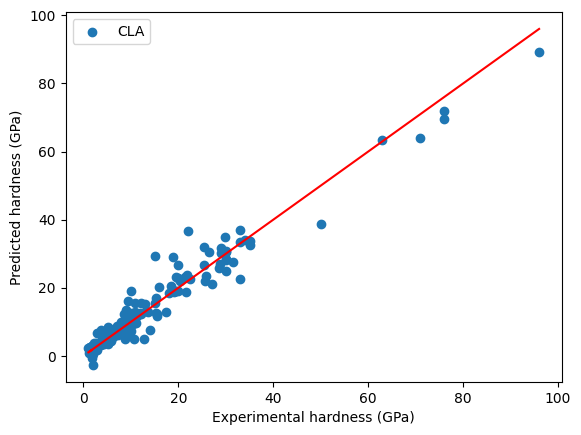

In [21]:
plt.plot(H_exp, H_exp, color='red')
plt.scatter(H_exp, H_cla, label='CLA')
plt.legend()
plt.xlabel("Experimental hardness (GPa)")
plt.ylabel("Predicted hardness (GPa)")

Text(0, 0.5, 'Predicted hardness (GPa)')

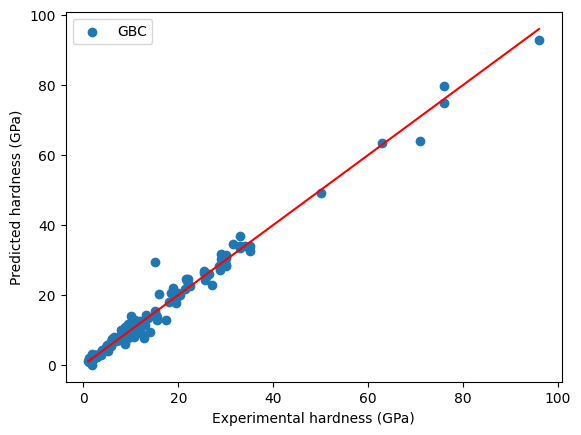

In [22]:
plt.plot(H_exp, H_exp, color='red')
plt.scatter(H_exp, H_gbc, label='GBC')
plt.legend()
plt.xlabel("Experimental hardness (GPa)")
plt.ylabel("Predicted hardness (GPa)")

Text(0, 0.5, 'Predicted hardness (GPa)')

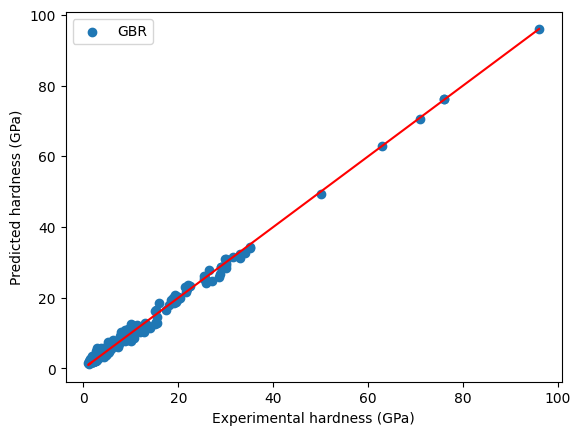

In [23]:
plt.plot(H_exp, H_exp, color='red')
plt.scatter(H_exp, H_gbr, label='GBR')
plt.legend()
plt.xlabel("Experimental hardness (GPa)")
plt.ylabel("Predicted hardness (GPa)")

In [24]:
from sklearn.metrics import r2_score
r2_cla = r2_score(H_exp, H_cla)
r2_gbc = r2_score(H_exp, H_gbc)
r2_gbr = r2_score(H_exp, H_gbr)
print("R2 CLA  = ", r2_cla)
print("R2 GBC  = ", r2_gbc)
print("R2 GBR  = ", r2_gbr)

R2 CLA  =  0.9475393556755983
R2 GBC  =  0.9831589025159361
R2 GBR  =  0.9944148710753455


# Write data to CSV file

In [25]:
df['Hx_cla'] = H_cla
df['yx_gbc'] = y_gbc
df['Hx_gbc'] = H_gbc
df['Hx_gbr'] = H_gbr

In [26]:
df.to_excel('prediction_dataset.xls', index=False)

ValueError: No engine for filetype: 'xls'

# The Classic Algorithm

In [27]:
csyst = 'Cubic'
bandgap = 'Semiconductor'
density = 'High'
cla_1 = 'n/a'
cla_2 = 'n/a'
cla_3 = 'n/a'

In [28]:
if csyst == 'Cubic' and bandgap == 'Metal': 
    cla_1 = 'H1a'
if csyst == 'Hexagonal' and bandgap == 'Semiconductor':
    cla_1 = 'H1a'
if csyst == 'Tetragonal' and bandgap == 'Semiconductor':
    cla_1 = 'H1a'
if csyst == 'Hexagonal' and bandgap == 'Insulator':
    cla_1 = 'H1b'
if csyst == 'Cubic' and bandgap == 'Insulator':
    cla_1 = 'H2'
if csyst == 'Monoclinic' and bandgap == 'Insulator':
    cla_1 = 'H2'
if csyst == 'Orthorhombic' and bandgap == 'Insulator':
    cla_1 = 'H2'
if csyst == 'Orthorhombic' and bandgap == 'Semiconductor':
    cla_1 = 'H2'
if csyst == 'Trigonal' and bandgap == 'Insulator':
    cla_1 = 'H2'
if csyst == 'Trigonal' and bandgap == 'Metal':
    cla_1 = 'H2'
if csyst == 'Trigonal' and bandgap == 'Semiconductor':
    cla_1 = 'H2'
if csyst == 'Hexagonal' and bandgap == 'Metal':
    cla_1 = 'H4'
if csyst == 'Monoclinic' and bandgap == 'Metal':
    cla_1 = 'H4'
if csyst == 'Monoclinic' and bandgap == 'Semiconductor':
    cla_1 = 'H4'
if csyst == 'Orthorhombic' and bandgap == 'Metal':
    cla_1 = 'H4'
if csyst == 'Tetragonal' and bandgap == 'Insulator':
    cla_1 = 'H4'
if csyst == 'Tetragonal' and bandgap == 'Metal':
    cla_1 = 'H4'
if csyst == 'Triclinic' and bandgap == 'Metal':
    cla_1 = 'H4'
if csyst == 'Cubic' and bandgap == 'Semiconductor':
    cla_1 = 'H5'
if csyst == 'Triclinic' and bandgap == 'Insulator':
    cla_1 = 'H5'
if csyst == 'Triclinic' and bandgap == 'Semiconductor':
    cla_1 = 'H5'

In [29]:
cla_1

'H5'

In [30]:
if csyst == 'Cubic' and density == 'High':
    cla_2 = 'H1a'
if csyst == 'Cubic' and density == 'Low':
    cla_2 = 'H5'
if csyst == 'Cubic' and density == 'Medium':
    cla_2 = 'H1a'
if csyst == 'Hexagonal' and density == 'High':
    cla_2 = 'H4'
if csyst == 'Hexagonal' and density == 'Low':
    cla_2 = 'H1b'
if csyst == 'Hexagonal' and density == 'Medium':
    cla_2 = 'H4'
if csyst == 'Monoclinic' and density == 'Low':
    cla_2 = 'H1b'
if csyst == 'Monoclinic' and density == 'Medium':
    cla_2 = 'H4'
if csyst == 'Orthorhombic' and density == 'High':
    cla_2 = 'H1a'
if csyst == 'Orthorhombic' and density == 'Low':
    cla_2 = 'H2'
if csyst == 'Orthorhombic' and density == 'Medium':
    cla_2 = 'H4'
if csyst == 'Tetragonal' and density == 'High':
    cla_2 = 'H3'
if csyst == 'Tetragonal' and density == 'Low':
    cla_2 = 'H2'
if csyst == 'Tetragonal' and density == 'Medium':
    cla_2 = 'H4'
if csyst == 'Triclinic' and density == 'Low':
    cla_2 = 'H5'
if csyst == 'Triclinic' and density == 'Medium':
    cla_2 = 'H4'
if csyst == 'Trigonal' and density == 'Low':
    cla_2 = 'H2'
if csyst == 'Trigonal' and density == 'Medium':
    cla_2 = 'H4'

In [31]:
cla_2

'H1a'

In [32]:
if density == 'Low' and bandgap == 'Insulator':
    cla_3 = 'H2'
if density == 'Low' and bandgap == 'Metal':
    cla_3 = 'H2'
if density == 'Low' and bandgap == 'Semiconductor':
    cla_3 = 'H5'
if density == 'Medium' and bandgap == 'Insulator':
    cla_3 = 'H2'
if density == 'Medium' and bandgap == 'Metal':
    cla_3 = 'H4'
if density == 'Medium' and bandgap == 'Semiconductor':
    cla_3 = 'H4'
if density == 'High' and bandgap == 'Metal':
    cla_3 = 'H4'
if density == 'High' and bandgap == 'Semiconductor':
    cla_3 = 'H3'

In [33]:
cla_3

'H3'